# 03 - Churn Analysis
Define churn, quantify the churn rate, and identify which behaviors predict it.

**Business question:** Can we flag at-risk customers early enough to intervene, and what drives churn?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../scripts')
from churn_analysis import build_features, train_model, CHURN_THRESHOLD_DAYS

tx = pd.read_csv('../data/clean_transactions.csv')
features = build_features(tx)
print(f'Churn definition: no purchase in {CHURN_THRESHOLD_DAYS}+ days')
features.head()

Churn definition: no purchase in 90+ days


,customer_id,recency_days,frequency,monetary,avg_order_value,tenure_days,return_rate,churned
0,12346,325,12,77556.46,2281.072353,400,0.276596,1
1,12347,1,8,4921.53,22.169054,402,0.000000,0
2,12348,74,5,2019.40,39.596078,362,0.000000,0
3,12349,18,4,4428.69,25.306800,570,0.027778,0
4,12350,309,1,334.40,19.670588,0,0.000000,1


## Churn rate overview

Overall churn rate: 50.8%


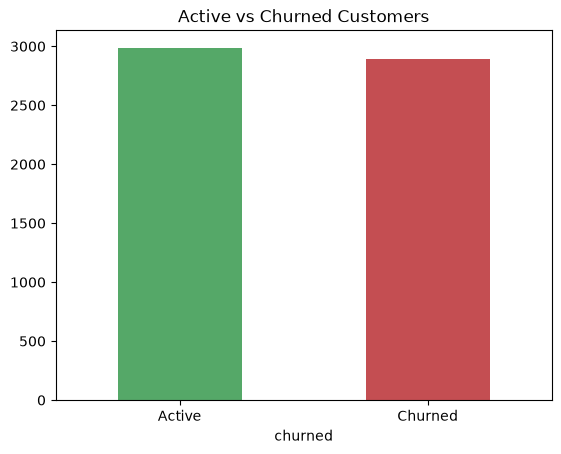

In [2]:
churn_rate = features['churned'].mean()
print(f'Overall churn rate: {churn_rate:.1%}')
features['churned'].value_counts().plot(kind='bar', color=['#55A868', '#C44E52'])
plt.xticks([0,1], ['Active', 'Churned'], rotation=0)
plt.title('Active vs Churned Customers')
plt.show()

## What predicts churn?
A logistic regression model on frequency, monetary value, average order value, tenure, and return rate.

In [3]:
model = train_model(features)

Classification report:
              precision    recall  f1-score   support

           0       0.73      0.70      0.71       723
           1       0.72      0.75      0.74       747

    accuracy                           0.73      1470
   macro avg       0.73      0.73      0.73      1470
weighted avg       0.73      0.73      0.73      1470

ROC-AUC: 0.795

Feature impact on churn likelihood (positive = increases churn risk):
        feature  coefficient
      frequency    -0.043847
    tenure_days    -0.003337
       monetary    -0.000045
avg_order_value     0.000087
    return_rate     1.377342


## Key takeaways
- Report the actual churn rate and top churn drivers once run on the real dataset
- Tenure and purchase frequency are typically the strongest churn predictors in retail
- Recommend: trigger a re-engagement campaign once a high-value customer crosses ~60 days of inactivity, ahead of the 90-day churn point